In [100]:

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

train = pd.read_csv("/content/drive/MyDrive/datasets/Laptop_Price_Prediction/train_data.csv")
test = pd.read_csv("/content/drive/MyDrive/datasets/Laptop_Price_Prediction/test_data.csv")

train.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [101]:
train.shape
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [102]:
# @title
print("Missing values in train:")
print(train.isnull().sum())

Missing values in train:
id                     0
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64


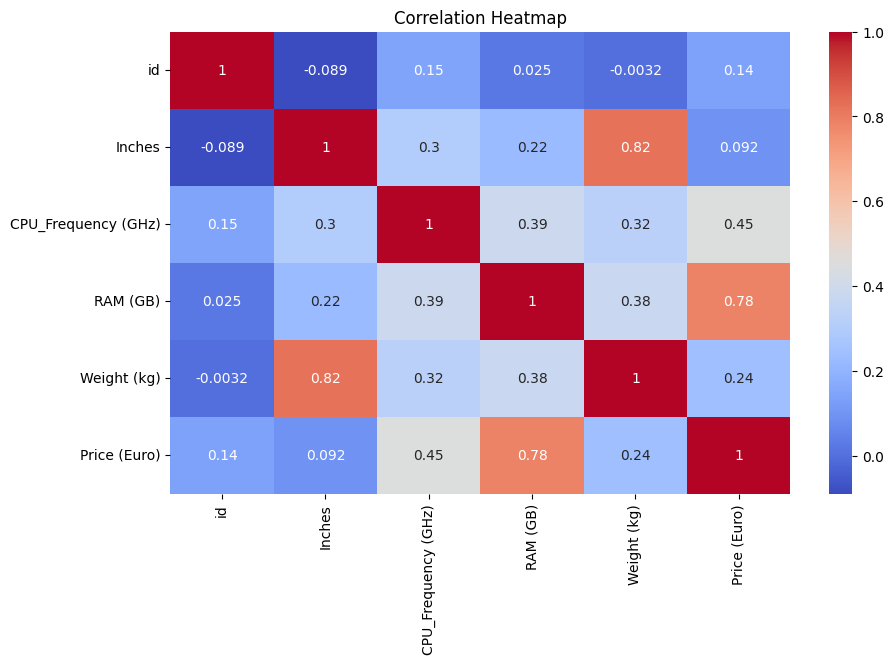

In [103]:
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

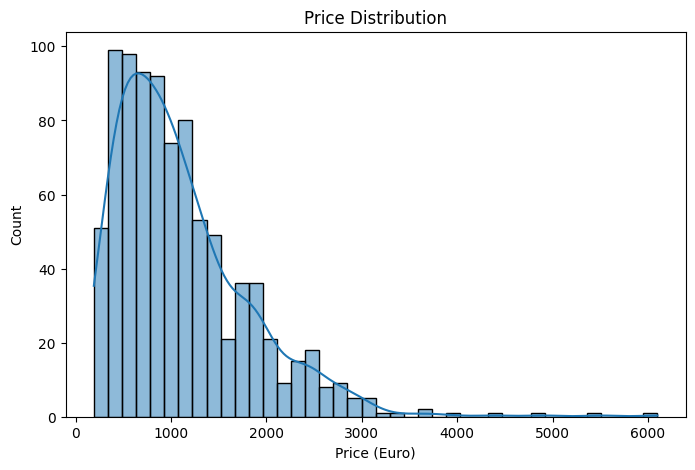

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(train["Price (Euro)"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

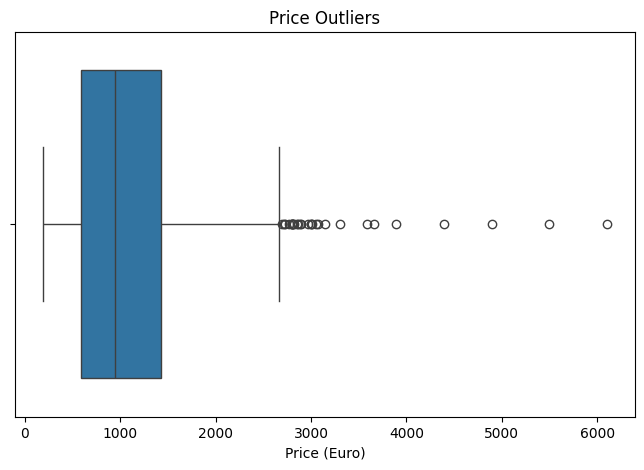

In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(x=train["Price (Euro)"])
plt.title("Price Outliers")
plt.show()

In [106]:
data= train.copy()

In [107]:
data = data.drop(["id","Product"], axis=1, errors="ignore")

In [108]:
data.head()

,Company,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [109]:
data = data.join(pd.get_dummies(data.Company, dtype=int))
data = data.drop("Company", axis=1)
data.head()

,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,...,LG,Lenovo,MSI,Mediacom,Microsoft,Razer,Samsung,Toshiba,Vero,Xiaomi
0,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,...,0,0,0,0,0,0,0,0,0,0
1,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,...,0,0,0,0,0,0,0,0,0,0
2,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,...,0,0,0,0,0,0,0,0,0,0
3,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,...,0,0,0,0,0,0,0,0,0,0
4,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,...,0,0,0,0,0,0,0,0,0,0


In [110]:
data = data.join(pd.get_dummies(data.TypeName, dtype=int))
data = data.drop("TypeName", axis=1)
data.head()

,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,...,Samsung,Toshiba,Vero,Xiaomi,2 in 1 Convertible,Gaming,Netbook,Notebook,Ultrabook,Workstation
0,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,...,0,0,0,0,0,0,0,0,1,0
1,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,...,0,0,0,0,0,0,0,0,1,0
2,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,...,0,0,0,0,0,0,0,1,0,0
3,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,...,0,0,0,0,0,0,0,0,1,0
4,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,...,0,0,0,0,0,0,0,0,1,0


In [111]:
data = data.join(pd.get_dummies(data.OpSys, dtype=int))
data = data.drop("OpSys", axis=1)
data.head()

,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,Weight (kg),...,Workstation,Android,Chrome OS,Linux,Mac OS X,No OS,Windows 10,Windows 10 S,Windows 7,macOS
0,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,1.37,...,0,0,0,0,0,0,0,0,0,1
1,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,1.34,...,0,0,0,0,0,0,0,0,0,1
2,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,1.86,...,0,0,0,0,0,1,0,0,0,0
3,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,1.83,...,0,0,0,0,0,0,0,0,0,1
4,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,1.37,...,0,0,0,0,0,0,0,0,0,1


In [112]:
data["ScreenResolution"] = data.ScreenResolution.str.split(" ").apply(lambda x: x[-1])
data["Screen Width"] = data.ScreenResolution.str.split("x").apply(lambda x: x[0])
data["Screen Height"] = data.ScreenResolution.str.split("x").apply(lambda x: x[1])
data = data.drop("ScreenResolution", axis=1)
data.head()

,Inches,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,Weight (kg),Price (Euro),...,Chrome OS,Linux,Mac OS X,No OS,Windows 10,Windows 10 S,Windows 7,macOS,Screen Width,Screen Height
0,13.3,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,1.37,1339.69,...,0,0,0,0,0,0,0,1,2560,1600
1,13.3,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,1.34,898.94,...,0,0,0,0,0,0,0,1,1440,900
2,15.6,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,1.86,575.00,...,0,0,0,1,0,0,0,0,1920,1080
3,15.4,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,1.83,2537.45,...,0,0,0,0,0,0,0,1,2880,1800
4,13.3,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,1.37,1803.60,...,0,0,0,0,0,0,0,1,2560,1600


In [113]:
if 'GPU_Company' in data.columns:
    data = data.join(pd.get_dummies(data.GPU_Company, dtype=int, prefix='GPU'))
    data = data.drop("GPU_Company", axis=1)
data.head()

,Inches,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Type,Weight (kg),Price (Euro),Acer,...,No OS,Windows 10,Windows 10 S,Windows 7,macOS,Screen Width,Screen Height,GPU_AMD,GPU_Intel,GPU_Nvidia
0,13.3,Intel,Core i5,2.3,8,128GB SSD,Iris Plus Graphics 640,1.37,1339.69,0,...,0,0,0,0,1,2560,1600,0,1,0
1,13.3,Intel,Core i5,1.8,8,128GB Flash Storage,HD Graphics 6000,1.34,898.94,0,...,0,0,0,0,1,1440,900,0,1,0
2,15.6,Intel,Core i5 7200U,2.5,8,256GB SSD,HD Graphics 620,1.86,575.00,0,...,1,0,0,0,0,1920,1080,0,1,0
3,15.4,Intel,Core i7,2.7,16,512GB SSD,Radeon Pro 455,1.83,2537.45,0,...,0,0,0,0,1,2880,1800,1,0,0
4,13.3,Intel,Core i5,3.1,8,256GB SSD,Iris Plus Graphics 650,1.37,1803.60,0,...,0,0,0,0,1,2560,1600,0,1,0


In [114]:
data = data.join(pd.get_dummies(data.CPU_Company, dtype=int, prefix='CPU'))
data = data.drop("CPU_Company", axis=1)
data.head()

,Inches,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Type,Weight (kg),Price (Euro),Acer,Apple,...,Windows 10 S,Windows 7,macOS,Screen Width,Screen Height,GPU_AMD,GPU_Intel,GPU_Nvidia,CPU_AMD,CPU_Intel
0,13.3,Core i5,2.3,8,128GB SSD,Iris Plus Graphics 640,1.37,1339.69,0,1,...,0,0,1,2560,1600,0,1,0,0,1
1,13.3,Core i5,1.8,8,128GB Flash Storage,HD Graphics 6000,1.34,898.94,0,1,...,0,0,1,1440,900,0,1,0,0,1
2,15.6,Core i5 7200U,2.5,8,256GB SSD,HD Graphics 620,1.86,575.00,0,0,...,0,0,0,1920,1080,0,1,0,0,1
3,15.4,Core i7,2.7,16,512GB SSD,Radeon Pro 455,1.83,2537.45,0,1,...,0,0,1,2880,1800,1,0,0,0,1
4,13.3,Core i5,3.1,8,256GB SSD,Iris Plus Graphics 650,1.37,1803.60,0,1,...,0,0,1,2560,1600,0,1,0,0,1


In [115]:
data["Memory Amount"] = data.Memory.str.split(" ").apply(lambda x: x[0])
data["Memory Type"] = data.Memory.str.split(" ").apply(lambda x: x[1])

def turn_memory_into_MB(value):
    if "GB" in value:
        return float(value.replace("GB", "")) * 1000
    elif "TB" in value:
        return float(value.replace("TB", "")) * 1000000
    return float(value.replace("MB", "")) # Handle cases where it's already in MB or has other units

data["Memory Amount"] = data["Memory Amount"].apply(turn_memory_into_MB)
data = data.drop("Memory", axis=1)
data.head()

,Inches,CPU_Type,CPU_Frequency (GHz),RAM (GB),GPU_Type,Weight (kg),Price (Euro),Acer,Apple,Asus,...,macOS,Screen Width,Screen Height,GPU_AMD,GPU_Intel,GPU_Nvidia,CPU_AMD,CPU_Intel,Memory Amount,Memory Type
0,13.3,Core i5,2.3,8,Iris Plus Graphics 640,1.37,1339.69,0,1,0,...,1,2560,1600,0,1,0,0,1,128000.0,SSD
1,13.3,Core i5,1.8,8,HD Graphics 6000,1.34,898.94,0,1,0,...,1,1440,900,0,1,0,0,1,128000.0,Flash
2,15.6,Core i5 7200U,2.5,8,HD Graphics 620,1.86,575.00,0,0,0,...,0,1920,1080,0,1,0,0,1,256000.0,SSD
3,15.4,Core i7,2.7,16,Radeon Pro 455,1.83,2537.45,0,1,0,...,1,2880,1800,1,0,0,0,1,512000.0,SSD
4,13.3,Core i5,3.1,8,Iris Plus Graphics 650,1.37,1803.60,0,1,0,...,1,2560,1600,0,1,0,0,1,256000.0,SSD


In [116]:
data = data.join(pd.get_dummies(data['Memory Type'], dtype=int))
data = data.drop("Memory Type", axis=1)
data.head()

,Inches,CPU_Type,CPU_Frequency (GHz),RAM (GB),GPU_Type,Weight (kg),Price (Euro),Acer,Apple,Asus,...,GPU_AMD,GPU_Intel,GPU_Nvidia,CPU_AMD,CPU_Intel,Memory Amount,Flash,HDD,Hybrid,SSD
0,13.3,Core i5,2.3,8,Iris Plus Graphics 640,1.37,1339.69,0,1,0,...,0,1,0,0,1,128000.0,0,0,0,1
1,13.3,Core i5,1.8,8,HD Graphics 6000,1.34,898.94,0,1,0,...,0,1,0,0,1,128000.0,1,0,0,0
2,15.6,Core i5 7200U,2.5,8,HD Graphics 620,1.86,575.00,0,0,0,...,0,1,0,0,1,256000.0,0,0,0,1
3,15.4,Core i7,2.7,16,Radeon Pro 455,1.83,2537.45,0,1,0,...,1,0,0,0,1,512000.0,0,0,0,1
4,13.3,Core i5,3.1,8,Iris Plus Graphics 650,1.37,1803.60,0,1,0,...,0,1,0,0,1,256000.0,0,0,0,1


In [117]:

data = data.drop("CPU_Type", axis=1)
data = data.drop("GPU_Type", axis=1)
data.head()

,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro),Acer,Apple,Asus,Chuwi,Dell,...,GPU_AMD,GPU_Intel,GPU_Nvidia,CPU_AMD,CPU_Intel,Memory Amount,Flash,HDD,Hybrid,SSD
0,13.3,2.3,8,1.37,1339.69,0,1,0,0,0,...,0,1,0,0,1,128000.0,0,0,0,1
1,13.3,1.8,8,1.34,898.94,0,1,0,0,0,...,0,1,0,0,1,128000.0,1,0,0,0
2,15.6,2.5,8,1.86,575.00,0,0,0,0,0,...,0,1,0,0,1,256000.0,0,0,0,1
3,15.4,2.7,16,1.83,2537.45,0,1,0,0,0,...,1,0,0,0,1,512000.0,0,0,0,1
4,13.3,3.1,8,1.37,1803.60,0,1,0,0,0,...,0,1,0,0,1,256000.0,0,0,0,1


In [118]:
data.columns

Index(['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)',
       'Price (Euro)', 'Acer', 'Apple', 'Asus', 'Chuwi', 'Dell', 'Fujitsu',
       'Google', 'HP', 'Huawei', 'LG', 'Lenovo', 'MSI', 'Mediacom',
       'Microsoft', 'Razer', 'Samsung', 'Toshiba', 'Vero', 'Xiaomi',
       '2 in 1 Convertible', 'Gaming', 'Netbook', 'Notebook', 'Ultrabook',
       'Workstation', 'Android', 'Chrome OS', 'Linux', 'Mac OS X', 'No OS',
       'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS', 'Screen Width',
       'Screen Height', 'GPU_AMD', 'GPU_Intel', 'GPU_Nvidia', 'CPU_AMD',
       'CPU_Intel', 'Memory Amount', 'Flash', 'HDD', 'Hybrid', 'SSD'],
      dtype='object')

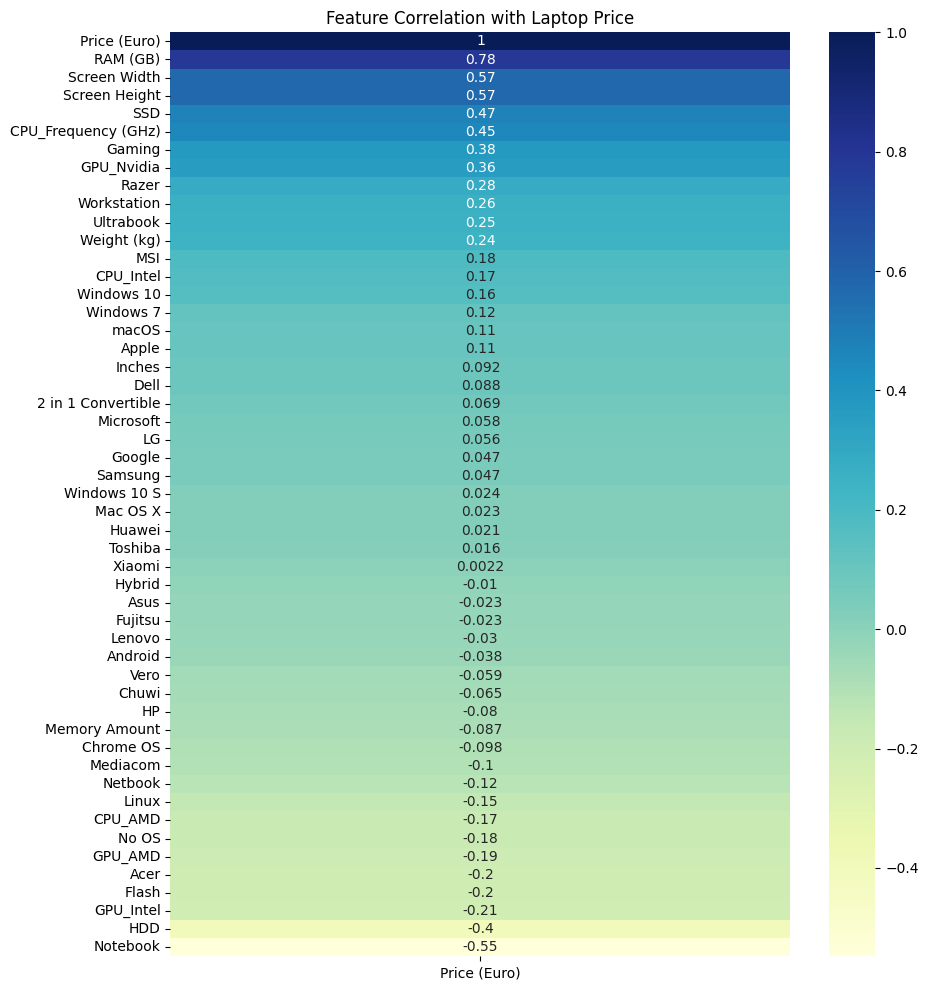

In [119]:
plt.figure(figsize=(10,12))

corr = data.corr()["Price (Euro)"].sort_values(ascending=False)

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Feature Correlation with Laptop Price")
plt.show()

In [120]:
target_corr= data.corr()["Price (Euro)"].apply(abs).sort_values()

In [121]:
target_corr

,Price (Euro)
Xiaomi,0.002211
Hybrid,0.010011
Toshiba,0.015847
Huawei,0.021050
Asus,0.022657
Mac OS X,0.022822
Fujitsu,0.022886
Windows 10 S,0.023732
Lenovo,0.029596
Android,0.037505


In [122]:
selected_features=target_corr[-24:].index
selected_features=list(selected_features)
selected_features

['Linux',
 'Windows 10',
 'CPU_AMD',
 'CPU_Intel',
 'No OS',
 'MSI',
 'GPU_AMD',
 'Acer',
 'Flash',
 'GPU_Intel',
 'Weight (kg)',
 'Ultrabook',
 'Workstation',
 'Razer',
 'GPU_Nvidia',
 'Gaming',
 'HDD',
 'CPU_Frequency (GHz)',
 'SSD',
 'Notebook',
 'Screen Height',
 'Screen Width',
 'RAM (GB)',
 'Price (Euro)']

In [123]:
limited_df=data[selected_features]
limited_df

,Linux,Windows 10,CPU_AMD,CPU_Intel,No OS,MSI,GPU_AMD,Acer,Flash,GPU_Intel,...,GPU_Nvidia,Gaming,HDD,CPU_Frequency (GHz),SSD,Notebook,Screen Height,Screen Width,RAM (GB),Price (Euro)
0,0,0,0,1,0,0,0,0,0,1,...,0,0,0,2.3,1,0,1600,2560,8,1339.69
1,0,0,0,1,0,0,0,0,1,1,...,0,0,0,1.8,0,0,900,1440,8,898.94
2,0,0,0,1,1,0,0,0,0,1,...,0,0,0,2.5,1,1,1080,1920,8,575.00
3,0,0,0,1,0,0,1,0,0,0,...,0,0,0,2.7,1,0,1800,2880,16,2537.45
4,0,0,0,1,0,0,0,0,0,1,...,0,0,0,3.1,1,0,1600,2560,8,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,1,0,0,1,0,0,0,0,0,1,...,0,0,1,1.1,0,1,768,1366,4,398.99
877,0,1,0,1,0,0,0,0,0,0,...,1,0,0,2.3,1,0,1080,1920,8,935.00
878,0,1,0,1,0,0,0,0,0,0,...,1,0,0,2.5,1,1,1080,1920,4,912.50
879,0,1,0,1,0,0,0,0,0,1,...,0,0,0,2.5,1,1,1080,1920,4,839.00


<Axes: >

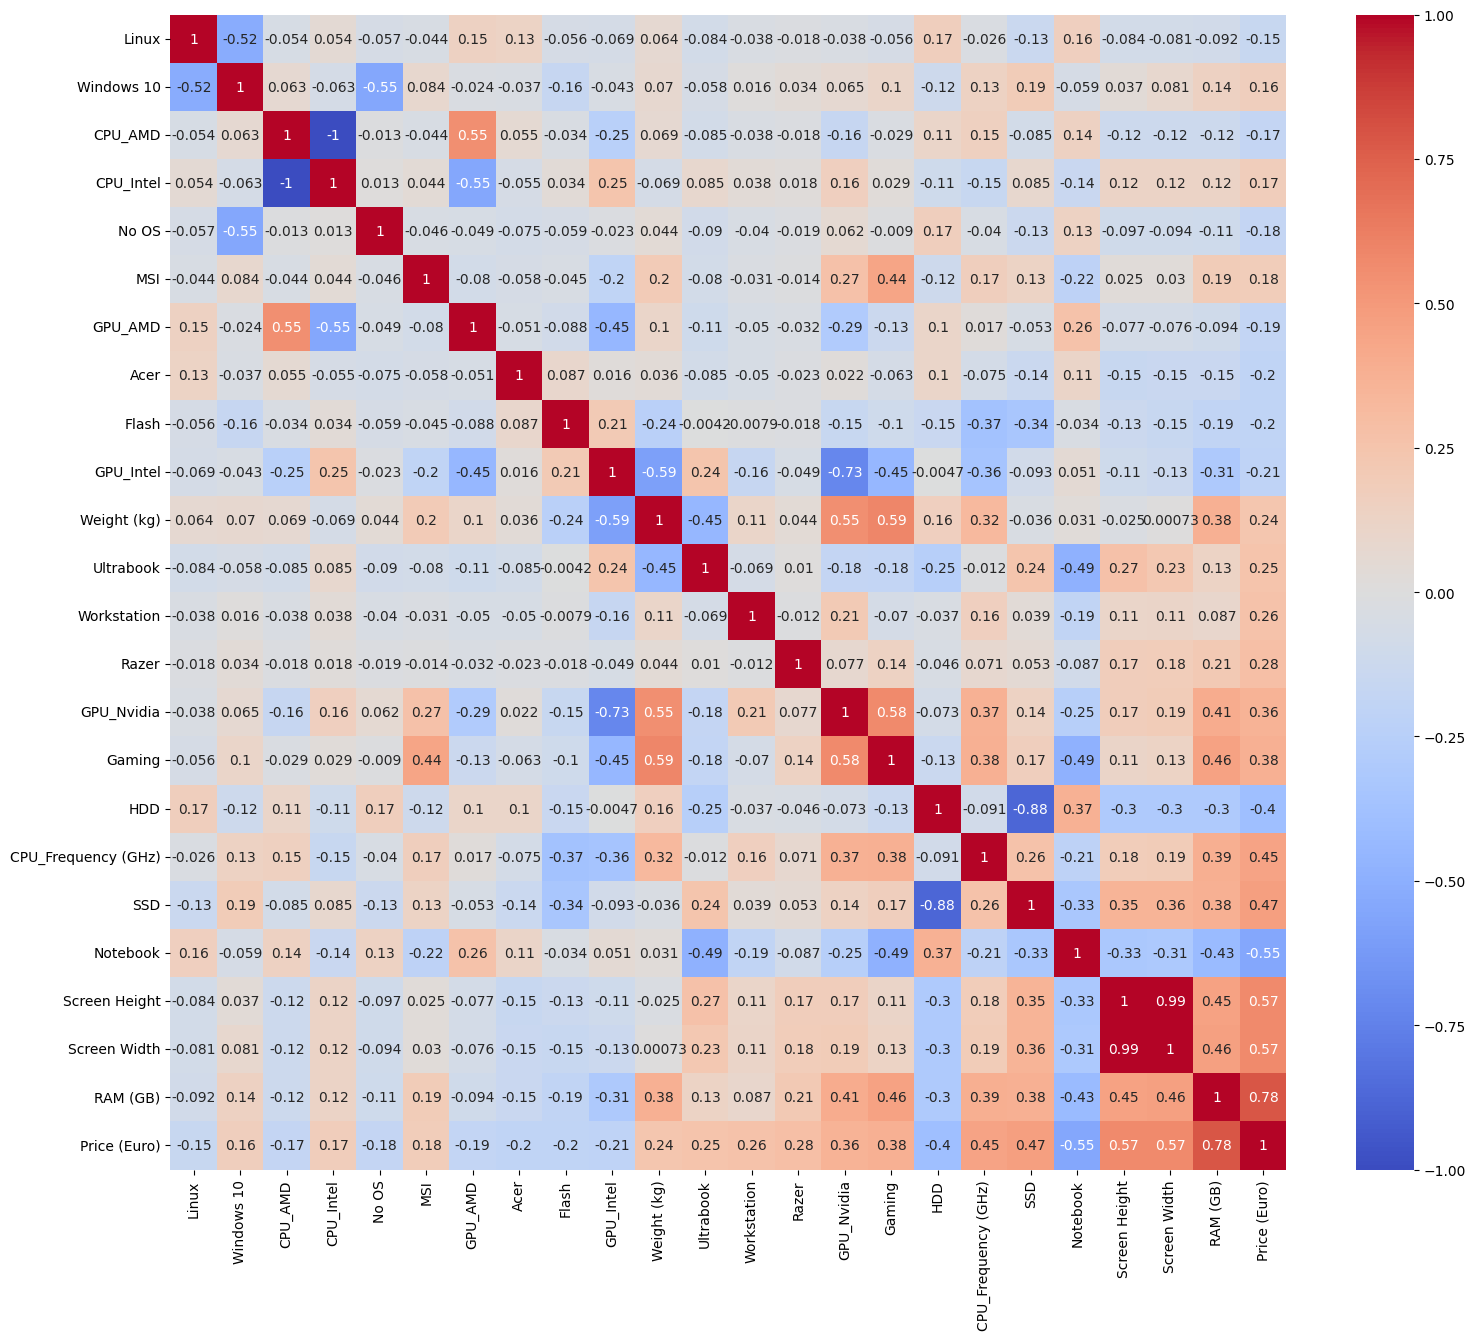

In [124]:
plt.figure(figsize=(18,15))
sns.heatmap(limited_df.corr(), annot=True, cmap="coolwarm")

In [125]:


X = limited_df.drop('Price (Euro)', axis=1)
y = limited_df['Price (Euro)']

#log transformatiom
y_log = np.log1p(y)

# We will use X and y_log for training our models.
print("Shape of feature matrix (X):", X.shape)
print("Shape of target vector (y_log):", y_log.shape)


Shape of feature matrix (X): (881, 23)
Shape of target vector (y_log): (881,)


In [126]:

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

#
# ensures that polynomial features are generated and scaled correctly within each fold of the cross-validation.
poly_reg_pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=10.0))
])


models = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    "Polynomial Regression (Deg 2)": poly_reg_pipeline,
    "Ridge Regression": Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    "Lasso Regression": Pipeline([('scaler', StandardScaler()), ('model', Lasso())]),
    "Decision Tree": Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor(random_state=42))])
}


In [127]:
# Set up the K-Fold strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)


cv_results = {}

print("--- Running 5-Fold Cross-Validation ---")
for name, model in models.items():
    # Calculate R-squared scores
    r2_scores = cross_val_score(model, X, y_log, cv=kf, scoring='r2', n_jobs=-1)

    # Calculate MAE scores (using negative MAE as scikit-learn maximizes scores)
    mae_scores = -cross_val_score(model, X, y_log, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

    # Calculate RMSE scores
    rmse_scores = np.sqrt(-cross_val_score(model, X, y_log, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))

    cv_results[name] = {
        'Mean R-squared': np.mean(r2_scores),
        'Std R-squared': np.std(r2_scores),
        'Mean MAE': np.mean(mae_scores),
        'Std MAE': np.std(mae_scores),
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores)
    }
    print(f"Completed: {name}")


print("\n--- Cross-Validation Results ---")
for name, metrics in cv_results.items():
    print(f"Model: {name}")
    print(f"  Mean R-squared: {metrics['Mean R-squared']:.4f} (+/- {metrics['Std R-squared']:.4f})")
    print(f"  Mean MAE: {metrics['Mean MAE']:.4f} (log scale)")
    print(f"  Mean RMSE: {metrics['Mean RMSE']:.4f} (log scale)\n")


--- Running 5-Fold Cross-Validation ---
Completed: Linear Regression
Completed: Polynomial Regression (Deg 2)
Completed: Ridge Regression
Completed: Lasso Regression
Completed: Decision Tree

--- Cross-Validation Results ---
Model: Linear Regression
  Mean R-squared: 0.7992 (+/- 0.0212)
  Mean MAE: 0.2192 (log scale)
  Mean RMSE: 0.2760 (log scale)

Model: Polynomial Regression (Deg 2)
  Mean R-squared: 0.8346 (+/- 0.0186)
  Mean MAE: 0.1955 (log scale)
  Mean RMSE: 0.2504 (log scale)

Model: Ridge Regression
  Mean R-squared: 0.7993 (+/- 0.0211)
  Mean MAE: 0.2192 (log scale)
  Mean RMSE: 0.2759 (log scale)

Model: Lasso Regression
  Mean R-squared: -0.0052 (+/- 0.0064)
  Mean MAE: 0.5060 (log scale)
  Mean RMSE: 0.6197 (log scale)

Model: Decision Tree
  Mean R-squared: 0.7570 (+/- 0.0112)
  Mean MAE: 0.2240 (log scale)
  Mean RMSE: 0.3045 (log scale)



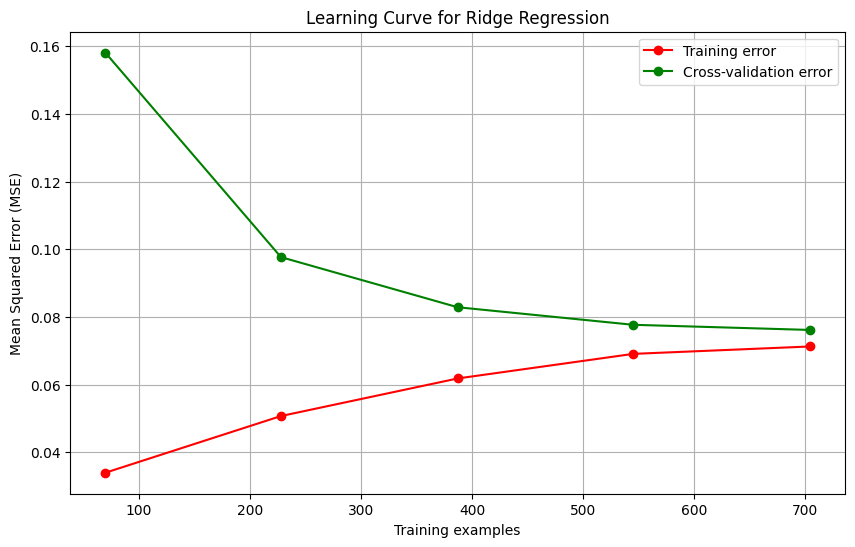

In [128]:
def plot_learning_curves(estimator, title, X, y, cv, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate and plot the learning curve for an estimator.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Mean Squared Error (MSE)")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring="neg_mean_squared_error")

    # We work with the negative of the scores to get positive MSE
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training error")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation error")
    plt.legend(loc="best")
    return plt


ridge_pipeline = models["Ridge Regression"]
plot_learning_curves(ridge_pipeline, "Learning Curve for Ridge Regression", X, y_log, cv=kf)
plt.show()


In [129]:
from sklearn.model_selection import GridSearchCV

print("\n==== HYPERPARAMETER TUNING =====\n")


# Ridge Regression

ridge_pipeline = models["Ridge Regression"]

ridge_param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\n--- Grid Search: Ridge Regression ---")
ridge_grid.fit(X, y_log)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV Score:", ridge_grid.best_score_)

best_ridge_model = ridge_grid.best_estimator_



#  Polynomial Regression

poly_pipeline = models["Polynomial Regression (Deg 2)"]

poly_param_grid = {
    'poly_features__degree': [1, 2, 3, 4]
}

poly_grid = GridSearchCV(
    estimator=poly_pipeline,
    param_grid=poly_param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\n--- Grid Search: Polynomial Regression ---")
poly_grid.fit(X, y_log)

print("Best Polynomial Parameters:", poly_grid.best_params_)
print("Best Polynomial CV Score:", poly_grid.best_score_)

best_poly_model = poly_grid.best_estimator_



#  Decision Tree

tree_pipeline = models["Decision Tree"]

tree_param_grid = {
    'model__max_depth': [3, 5, 10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\n--- Grid Search: Decision Tree ---")
tree_grid.fit(X, y_log)

print("Best Tree Parameters:", tree_grid.best_params_)
print("Best Tree CV Score:", tree_grid.best_score_)

best_tree_model = tree_grid.best_estimator_



# Compare Best Models


print("\n==== BEST MODELS SUMMARY ====\n")

print("Best Ridge Params:", ridge_grid.best_params_)
print("Best Polynomial Params:", poly_grid.best_params_)
print("Best Decision Tree Params:", tree_grid.best_params_)


# Select the best model based on CV score
models_scores = {
    "Ridge": ridge_grid.best_score_,
    "Polynomial": poly_grid.best_score_,
    "Decision Tree": tree_grid.best_score_
}

best_model_name = max(models_scores, key=models_scores.get)

print("\nBest Model Overall:", best_model_name)

if best_model_name == "Ridge":
    best_tuned_model = best_ridge_model
elif best_model_name == "Polynomial":
    best_tuned_model = best_poly_model
else:
    best_tuned_model = best_tree_model




================ HYPERPARAMETER TUNING ================


--- Grid Search: Ridge Regression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Ridge Parameters: {'model__alpha': 10}
Best Ridge CV Score: -0.07609847667269615

--- Grid Search: Polynomial Regression ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Polynomial Parameters: {'poly_features__degree': 2}
Best Polynomial CV Score: -0.06272051296261519

--- Grid Search: Decision Tree ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Tree Parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best Tree CV Score: -0.07486615458750849

================ BEST MODELS SUMMARY ================

Best Ridge Params: {'model__alpha': 10}
Best Polynomial Params: {'poly_features__degree': 2}
Best Decision Tree Params: {'model__max_depth': 15, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Best Model Overall: Polynomial


In [130]:
# 1. Preprocess the test data using the same steps as the training data


def preprocess_data(df):
    # a copy to avoid modifying the original dataframe
    df_processed = df.copy()


    df_processed = df_processed.drop(["id", "Product"], axis=1, errors="ignore")


    df_processed = pd.get_dummies(df_processed, columns=['Company', 'TypeName', 'OpSys', 'CPU_Company'], dtype=int)


    df_processed["ScreenResolution"] = df_processed.ScreenResolution.str.split(" ").apply(lambda x: x[-1])
    df_processed["Screen Width"] = df_processed.ScreenResolution.str.split("x").apply(lambda x: x[0])
    df_processed["Screen Height"] = df_processed.ScreenResolution.str.split("x").apply(lambda x: x[1])
    df_processed = df_processed.drop("ScreenResolution", axis=1)


    df_processed["Memory Amount"] = df_processed.Memory.str.split(" ").apply(lambda x: x[0])
    df_processed["Memory Type"] = df_processed.Memory.str.split(" ").apply(lambda x: ' '.join(x[1:])) # Handle multi-word types

    def turn_memory_into_MB(value):
        if "GB" in value:
            return float(value.replace("GB", "")) * 1000
        elif "TB" in value:
            return float(value.replace("TB", "")) * 1000000
        return float(value.replace("MB", ""))

    df_processed["Memory Amount"] = df_processed["Memory Amount"].apply(turn_memory_into_MB)
    df_processed = df_processed.drop("Memory", axis=1)
    df_processed = pd.get_dummies(df_processed, columns=['Memory Type'], dtype=int)


    df_processed = df_processed.drop(["CPU_Type", "GPU_Type"], axis=1, errors='ignore')

    return df_processed

# Preprocess the test data
test_processed = preprocess_data(test)

# Align columns
# We add the missing columns to the test set and fill them with 0.
train_cols = X.columns
missing_cols = set(train_cols) - set(test_processed.columns)
for c in missing_cols:
    test_processed[c] = 0

# Ensure the order of columns is the same as in the training set
test_processed = test_processed[train_cols]


# predictions on the preprocessed test set
print("\n--- Evaluating Final Model on Test Set ---")
final_predictions_log = best_tuned_model.predict(test_processed)

# Inverse transform the predictions to get the actual price
# Since we trained on the log of the price, we need to convert back.
final_predictions = np.expm1(final_predictions_log)


print("\nExample Predictions on the Test Set:")
print(final_predictions[:5])






--- Evaluating Final Model on Test Set ---

Example Predictions on the Test Set:
[425.71666386 296.42399994 451.08436625 345.03673477 370.54106799]


In [131]:

import pandas as pd
test = pd.read_csv("/content/drive/MyDrive/datasets/Laptop_Price_Prediction/test_data.csv")
test_ids = test['id']

#submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'Price (Euro)': final_predictions
})

#Save submission file
submission.to_csv('/content/submission.csv', index=False)

print("Submission file created successfully!")
print(submission.head())

Submission file created successfully!
    id  Price (Euro)
0  882    425.716664
1  883    296.424000
2  884    451.084366
3  885    345.036735
4  886    370.541068


In [132]:
#from google.colab import files
#files.download('/content/submission.csv')